In [2]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

cancer_data = load_breast_cancer()
df = pd.DataFrame(data=cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target
df.head()



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"shape of training data is : {X_train.shape}")



shape of training data is : (455, 30)


In [4]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy}")
print(classification_report(y_test, y_pred))

Accuracy : 0.9298245614035088
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        43
           1       0.94      0.94      0.94        71

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



Feature at root is : mean concave points


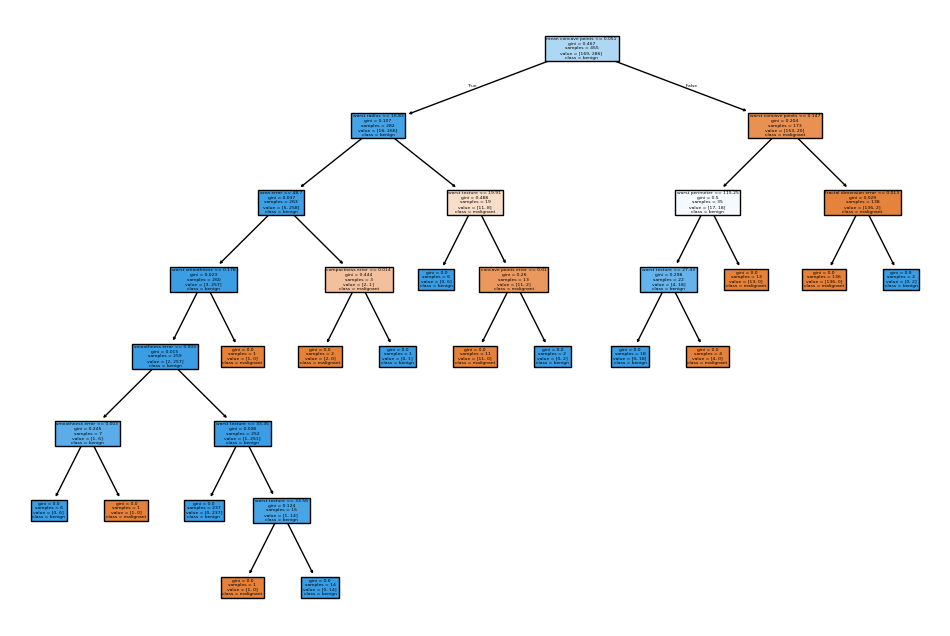

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree = plot_tree(model, filled=True, feature_names=cancer_data.feature_names, class_names=cancer_data.target_names)

root_idx = model.tree_.feature[0]
root_name = cancer_data.feature_names[root_idx]
print(f"Feature at root is : {root_name}")

plt.show()

In [45]:
no_pruning_model = DecisionTreeClassifier()
pruning_model = DecisionTreeClassifier(max_depth=4)

no_pruning_model.fit(X_train, y_train)
pruning_model.fit(X_train, y_train)

y_pred_t1 = no_pruning_model.predict(X_train)
y_pred_t2 = pruning_model.predict(X_train)
y_pred_1 = no_pruning_model.predict(X_test)
y_pred_2 = pruning_model.predict(X_test)

accuracy_tr1 = accuracy_score(y_train, y_pred_t1)
accuracy_tr2 = accuracy_score(y_train, y_pred_t2)
accuracy_t1 = accuracy_score(y_test, y_pred_1)
accuracy_t2 = accuracy_score(y_test, y_pred_2)

print(f"Accuracy on train set is : prunning {accuracy_tr1} no-prunning {accuracy_tr2}")
print(f"Accuracy on test set is : prunning {accuracy_t1} no-prunning {accuracy_t2}")



Accuracy on train set is : prunning 1.0 no-prunning 0.9956043956043956
Accuracy on test set is : prunning 0.9298245614035088 no-prunning 0.9473684210526315


In [50]:
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)

print(f"Accuracy decision tree no prunning : {accuracy_t1}",end=('\n'))
print(f"Accuracy decision tree prunning : {accuracy_t2}",end=('\n'))
print(f"Accuracy random forest : {accuracy}",end=('\n\n'))

feature_importances = model.feature_importances_
df_importance = pd.Series(feature_importances, index=cancer_data.feature_names)

df_importance_sorted = df_importance.sort_values(ascending=False)
top5_feature = df_importance_sorted.head(5)
print(f"Feature importance first 5 feature.",end=('\n'))
for rank,(name,score) in enumerate(top5_feature.items()):
    print(f"{rank+1}. {name} : {score}")

Accuracy decision tree no prunning : 0.9298245614035088
Accuracy decision tree prunning : 0.9473684210526315
Accuracy random forest : 0.9649122807017544

Feature importance first 5 feature.
1. worst area : 0.14029901486154162
2. worst perimeter : 0.1314057289524773
3. worst concave points : 0.12441503023796631
4. worst radius : 0.1021502013393538
5. mean concave points : 0.09908267347423053
